In [1]:
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt
import pickle
from spectral.io import envi

from scipy.signal import medfilt, savgol_filter
from scipy.interpolate import splrep, splev, interp1d

from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_analytical
from isofit.configs import configs
from isofit.core.geometry import Geometry

%matplotlib widget

In [2]:
os.chdir('/store/carroll/col/data/2025/')

In [3]:
out_figs = '/store/carroll/col/figs/'

rccs_raw = np.loadtxt('rccs/rcc_snodgrass_mean_20251117.txt')

base_dir = 'rccs/'

wl = np.loadtxt('/store/carroll/col/data/wavelengths_neon.txt')[:,1]*1000
wl_nan = np.loadtxt('/store/carroll/col/data/wl_nan.txt')

def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))

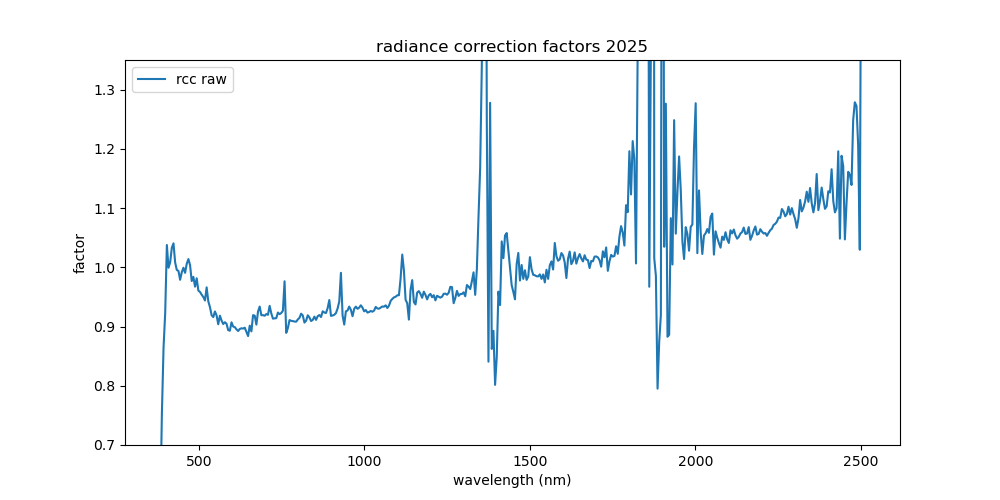

In [4]:
fig = plt.figure(figsize=(10,5))

plt.plot(wl, rccs_raw, label='rcc raw')

plt.xlabel('wavelength (nm)')
plt.ylabel('factor')
plt.ylim(0.7, 1.35)
plt.title('radiance correction factors 2025')
plt.legend()

plt.savefig(os.path.join(out_figs, 'raw_rccs_2025.png'), dpi=300)

plt.show()

In [5]:
# load single px rdn, obs, loc data
fp_single_px = '/store/carroll/col/data/2025/rccs/single_pxs.pkl'
with open(fp_single_px, 'rb') as f:
    single_px = pickle.load(f)

# identify test flights
fids = list(single_px.keys())
test_fids = [
    'NIS01_20250626_165802_airpark',
    'NIS01_20250628_160551_airpark',
    'NIS01_20250702_162359_coal_creek',
    'NIS01_20250614_177824_almo',
    'NIS01_20250709_164963_upta',
    'NIS01_20250709_166260_upta'
]

In [6]:
# set up labels for figures
rfl_labels = []
for fid in test_fids:
    targets = single_px[fid].keys()
    for k in targets:
        rfl_labels.append(f'{fid}_{k}')

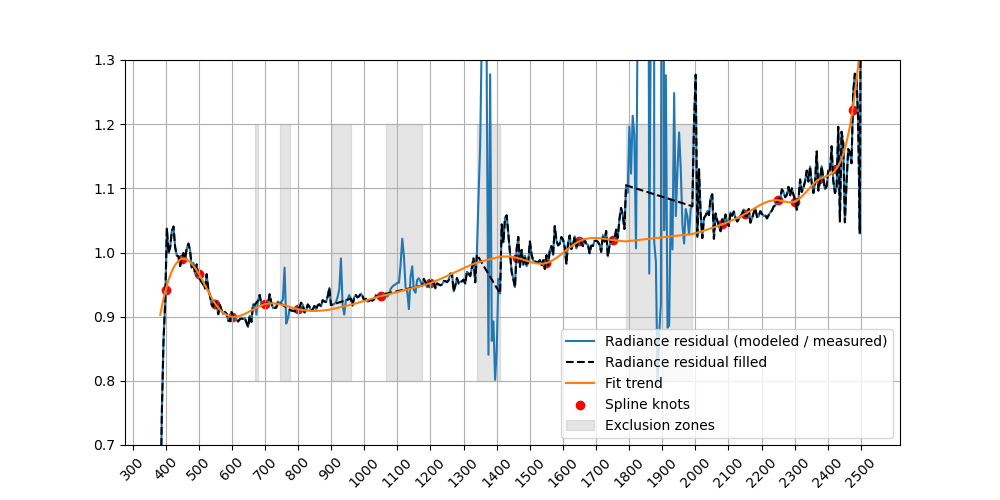

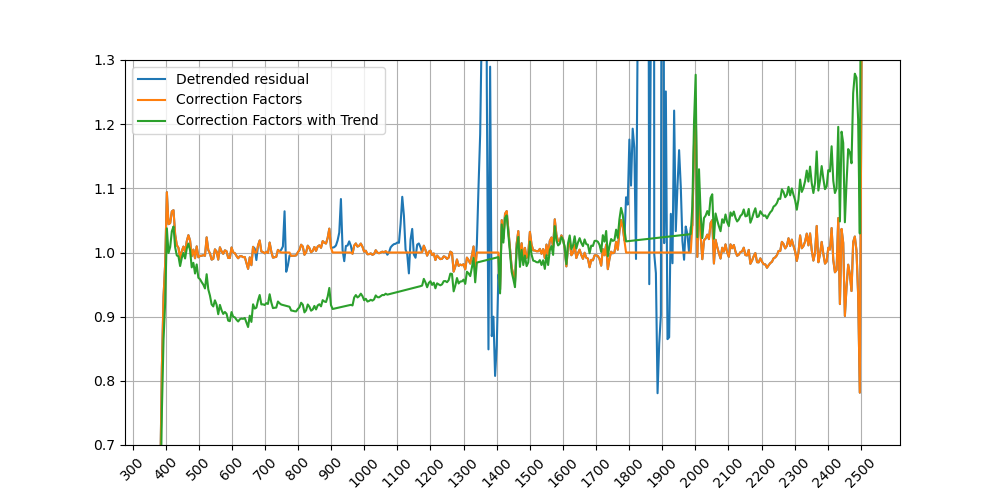

In [9]:
# define exclusion zones, adjust rccs

wl = np.loadtxt('/store/carroll/col/data/wavelengths_neon.txt')[:,1]*1000

wl = wl/1000

# Now it's time for the science/art - let's do some work to try and only get
# the influence of calibration, not the atmosphere.

def wl2ind(wl0):
    return np.argmin(np.abs(wl - wl0))

def ind2wl(ind0):
    return wl[ind0]

radiance_ratio = np.loadtxt('rccs/rcc_snodgrass_mean_20251117.txt')

radiance_ratio_adjusted = radiance_ratio.copy()
knots = np.array([400,450,500,550,600,700,800,1050,1200,1460,1550,1650,1750,2080,2150,2250,2300,2375,2425, 2475], dtype=np.float32)/1000.
ignore_zones = [[0.7457, 0.7755], [0.9024, 0.960], [1.0665, 1.1735], [1.34, 1.410], [1.79, 1.99], # atm absorption regions (narrower)
                # [[0.7457, 0.7755], [0.9024, 0.960], [1.0665, 1.1735], [1.33, 1.465], [1.77, 2.05], # water absorption regions
                [0.669, 0.679],
                # [1.640,1.670], 
                # [2.096, 2.350], # identified systematics in 2018
               ] 
               # [0.669, 0.679], [2.096, 2.192], [2.231,2.269], [2.306, 2.317], [2.430, 2.460]] # identified systematics - less conservative (2018)

knot_average_window = 1

for a, b in ignore_zones:
    wl_subset = wl[np.logical_and(wl > a, wl < b)]
    radiance_ratio_adjusted[np.logical_and(wl > a, wl < b)] = interp1d([a,b],[radiance_ratio_adjusted[wl2ind(a)],radiance_ratio_adjusted[wl2ind(b)]])(wl_subset)

inds = np.array([wl2ind(q) for q in knots])
spline_y = np.array([np.mean(radiance_ratio_adjusted[x-knot_average_window:x+knot_average_window+1]) for x in inds])
spline = splrep(knots,spline_y)
y_trend  = splev(wl, spline)


y_detrend = radiance_ratio/y_trend
y_correction = radiance_ratio/y_trend
for ez in ignore_zones:
    y_correction[np.logical_and(wl > ez[0], wl < ez[1])] = 1
    y_trend[np.logical_and(wl > ez[0], wl < ez[1])] = interp1d([ez[0],ez[1]],[y_trend[wl2ind(ez[0])],y_trend[wl2ind(ez[1])]])(wl[np.logical_and(wl > ez[0], wl < ez[1])])


wl = wl*1000

plt.figure(figsize=(10, 5))
plt.plot(wl, radiance_ratio, label='Radiance residual (modeled / measured)')
plt.plot(wl, radiance_ratio_adjusted, label='Radiance residual filled', c='black',ls='--')
plt.plot(wl, y_trend, label='Fit trend')
plt.scatter(knots*1000, spline_y, color='r', label='Spline knots')
for _el, el in enumerate(ignore_zones):
    if _el == 0:
        plt.fill_between(np.array(el)*1000, 0.8, 1.2, color='grey', alpha=0.2, label='Exclusion zones')
    else:
        plt.fill_between(np.array(el)*1000, 0.8, 1.2, color='grey', alpha=0.2)

plt.ylim([0.7, 1.3])
plt.xticks(np.arange(300,2600,100),rotation=45)
plt.grid()
plt.legend()

plt.figure(figsize=(10, 5))
plt.plot(wl, y_detrend, label='Detrended residual')
plt.plot(wl, y_correction, label='Correction Factors')
plt.plot(wl, y_correction*y_trend, label='Correction Factors with Trend')
plt.ylim([0.7, 1.3])
plt.xticks(np.arange(300,2600,100),rotation=45)
plt.grid()
plt.legend()

In [72]:
fp_out = os.path.join(base_dir, 'rcc_snodgrass_mean_20251117_detrended.txt')
np.savetxt(fp_out, y_correction)

In [73]:
rcc_detrended = np.loadtxt(fp_out)

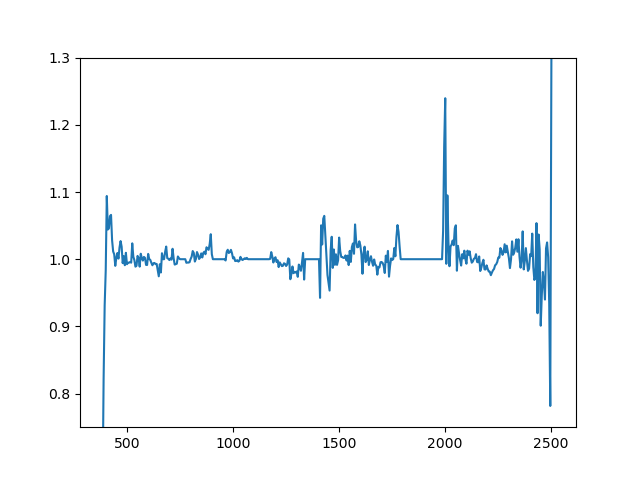

In [74]:
# export detrended rccs

fig = plt.figure()
plt.plot(wl, rcc_detrended)
plt.ylim(0.75, 1.3)
plt.show()

In [75]:
# retrieve rfl w adjusted radiance for each bright, dark test target

alg_rfl_with_rcc = []
alg_rfl_without_rcc = []

for fid in test_fids:
    targets = single_px[fid].keys()
    if fid=='NIS01_20250614_177824_almo':
        fid_ = 'NIS01_20250614_175924_almo'
    elif fid=='NIS01_20250709_164963_upta':
        fid_ = 'NIS01_20250709_164959_upta'
    elif fid=='NIS01_20250709_166260_upta':
        fid_ = 'NIS01_20250709_165959_upta'
    else:
        fid_ = fid
    for k in targets:
        working_dir = os.path.join(base_dir, fid_)

        rdn = single_px[fid][k]['rdn']
        obs = single_px[fid][k]['obs']
        loc = single_px[fid][k]['loc']
        
        # load config as-is
        fp_config = glob(os.path.join(working_dir, 'config', f'*_isofit.json'))[0]
        config = configs.create_new_config(fp_config)
        
        # set up forward model, io, inversion according to config
        fm = ForwardModel(config)
        io = IO(config, fm)
        inv = Inversion(config, fm)
        
        # load the isofit geometry representation of the single pixel
        geom = Geometry(obs=obs, loc=loc)
        
        # adjust rdn
        meas = rdn.copy()
        meas = meas*rcc_detrended
        
        # retrieve rfl with rccs
        states=inv.invert(meas, geom)
        xa_surface = fm.surface.xa(states[0,...][fm.idx_surface].copy(), geom) # get surface prior mean
        x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
        x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, meas, geom)
        alg_rfl_with_rcc.append(x_alg)

        # retrieve rfl with no rccs
        states=inv.invert(rdn, geom)
        xa_surface = fm.surface.xa(states[0,...][fm.idx_surface].copy(), geom) # get surface prior mean
        x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
        x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, rdn, geom)
        alg_rfl_without_rcc.append(x_alg)

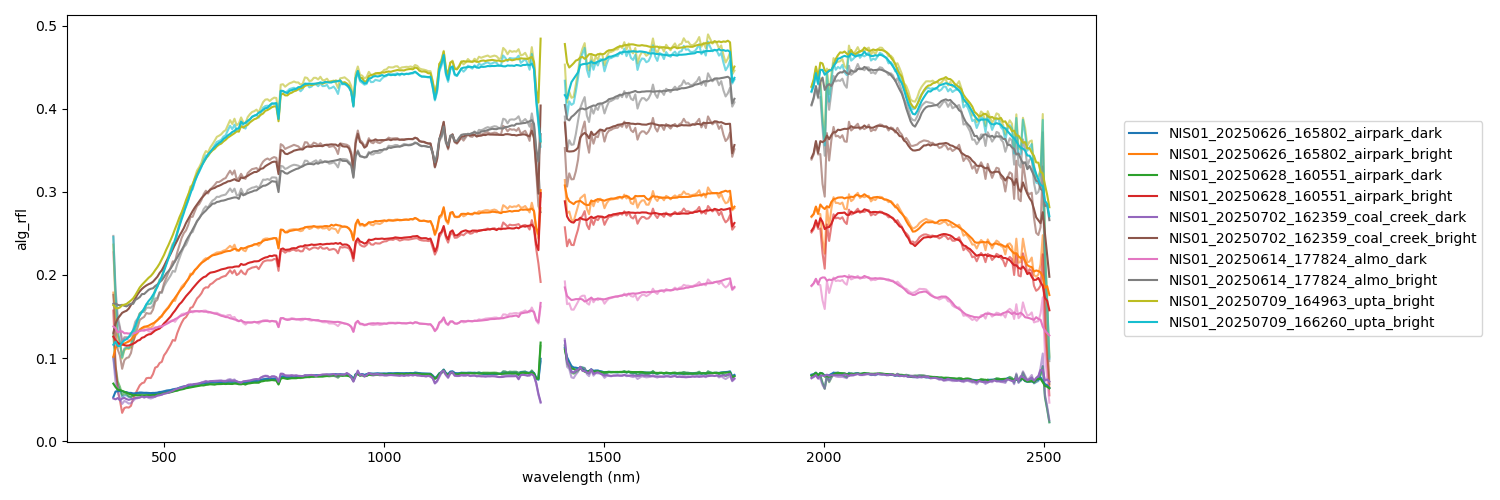

In [76]:
# viz alg rfl with and without rccs

fig = plt.figure(figsize=(15,5))

for i in range(len(alg_rfl_with_rcc)):
    plt.plot(wl_nan, alg_rfl_without_rcc[i], alpha=0.6)

for i in range(len(alg_rfl_with_rcc)):
    plt.plot(wl_nan, alg_rfl_with_rcc[i], label=rfl_labels[i])

plt.ylabel('alg_rfl')
plt.xlabel('wavelength (nm)')

plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()

plt.show()

In [62]:
closest_wl(2200)

363

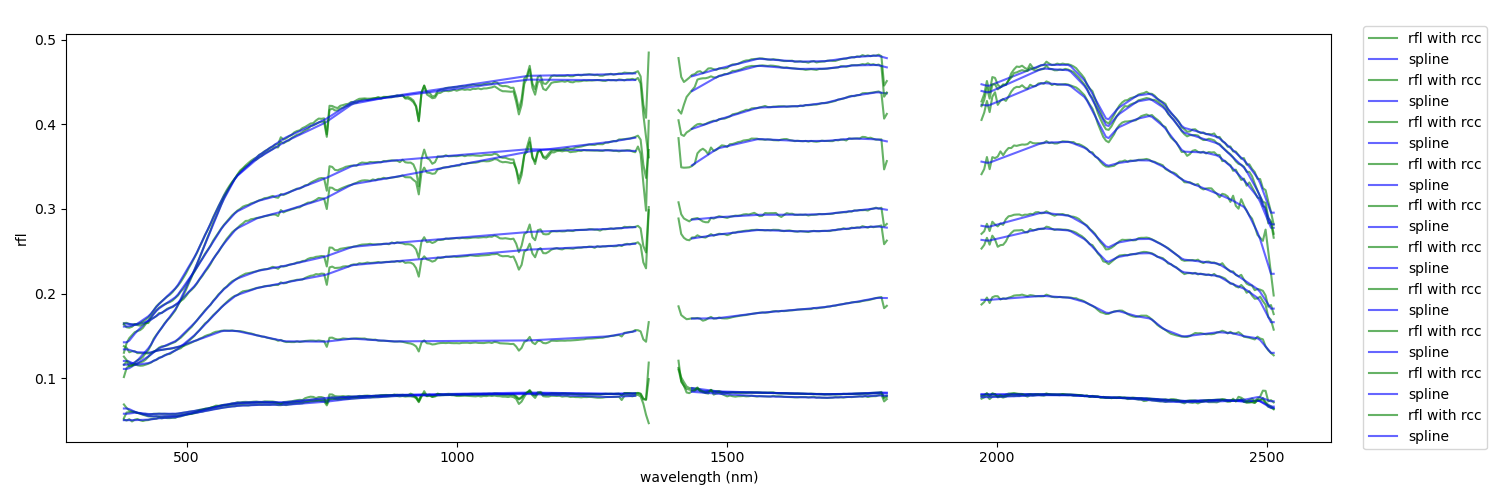

In [77]:
# set up rcc rfl interpolation

exp_arr = np.array([2,5,10,13,20,27,37,42,50,60,75,85,100,150,180,190,206,210,220,235,250,260,270,279,320,340,350,356,364,368,375,380,385,392,400,405,410,415,420,425])

bin_size = 2
exp_lis = [np.mean(wl_nan[x-bin_size:x+bin_size]) for x in exp_arr]

fig = plt.figure(figsize=(15,5))

for i in range(len(alg_rfl_with_rcc)):
    plt.plot(wl_nan, alg_rfl_with_rcc[i], alpha=0.6, label='rfl with rcc', color='green')
    rfl_lis = [np.mean(alg_rfl_with_rcc[i][x-bin_size:x+bin_size]) for x in exp_arr]
    interp = np.interp(wl_nan, exp_lis, rfl_lis)
    plt.plot(wl_nan, interp, alpha=0.6, color='blue', label='spline')

plt.ylabel('rfl')
plt.xlabel('wavelength (nm)')

plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()

plt.show()

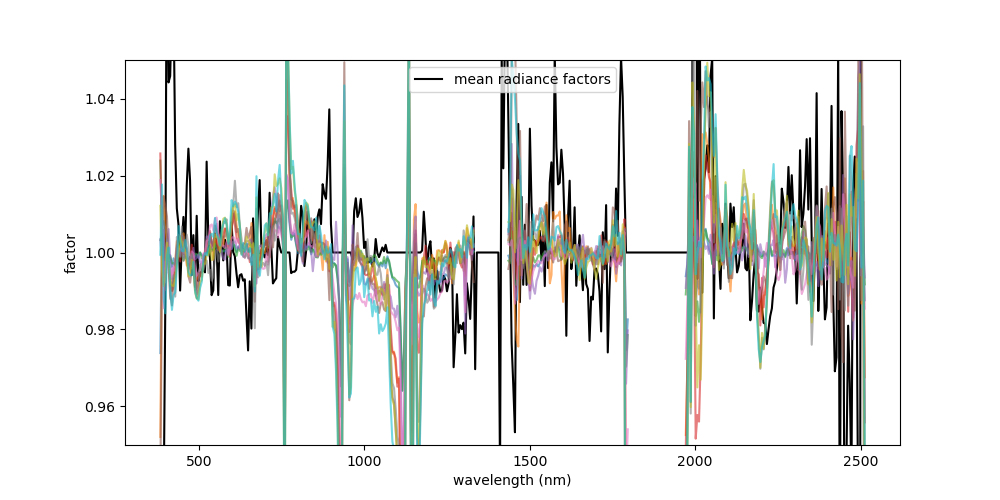

In [78]:
# visualize the delta between x_alg (from the rcc-adjusted rdn) and a smoothed linear interpolation of x_alg
# compare those deltas w/ rccs, across all bright/dark targets
# regions where the noise (deltas) are similar across targets and follow the trends of the rccs = regions we want to interpolate across

deltas = []

fig = plt.figure(figsize=(10,5))

plt.plot(wl, rcc_detrended, color='black', label='mean radiance factors')

for i in range(len(alg_rfl_with_rcc)):
    rfl_lis = [np.mean(alg_rfl_with_rcc[i][x-bin_size:x+bin_size]) for x in exp_arr]
    interp = np.interp(wl_nan, exp_lis, rfl_lis)
    delta = alg_rfl_with_rcc[i] - interp
    deltas.append(delta)
    plt.plot(wl_nan, delta*5+1, alpha=0.6)
plt.ylabel('factor')
plt.xlabel('wavelength (nm)')
plt.ylim(0.95, 1.05)
plt.legend()
plt.show()

1.0198247946821066 1.004527422761875
1.0126822918032135 1.0025554688851812


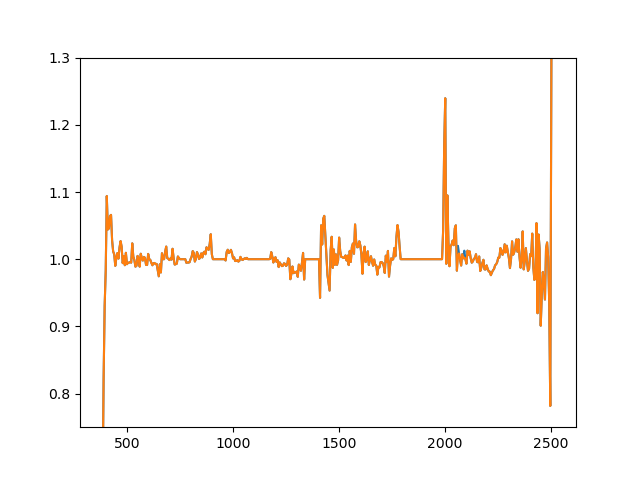

In [99]:
# Further adjustment... 

rcc_detrended_adjusted = rcc_detrended.copy()

i2061 = closest_wl(2061)
i2091 = closest_wl(2091)

rcc_detrended_adjusted[i2061] = rcc_detrended[i2061]*0.985
rcc_detrended_adjusted[i2091] = rcc_detrended[i2091]*0.99

print(rcc_detrended[i2061], rcc_detrended_adjusted[i2061])
print(rcc_detrended[i2091], rcc_detrended_adjusted[i2091])

fig = plt.figure()
plt.plot(wl, rcc_detrended, label='rcc_detrended')
plt.plot(wl, rcc_detrended_adjusted, label='rcc_detrended_adjusted')
plt.ylim(0.75, 1.3)
plt.xlim()
plt.show()

In [100]:
# retrieve rfl w adjusted radiance for each bright, dark test target
# with adjusted rccs

alg_rfl_with_rcc = []
alg_rfl_without_rcc = []

for fid in test_fids:
    targets = single_px[fid].keys()
    if fid=='NIS01_20250614_177824_almo':
        fid_ = 'NIS01_20250614_175924_almo'
    elif fid=='NIS01_20250709_164963_upta':
        fid_ = 'NIS01_20250709_164959_upta'
    elif fid=='NIS01_20250709_166260_upta':
        fid_ = 'NIS01_20250709_165959_upta'
    else:
        fid_ = fid
    for k in targets:
        working_dir = os.path.join(base_dir, fid_)

        rdn = single_px[fid][k]['rdn']
        obs = single_px[fid][k]['obs']
        loc = single_px[fid][k]['loc']
        
        # load config as-is
        fp_config = glob(os.path.join(working_dir, 'config', f'*_isofit.json'))[0]
        config = configs.create_new_config(fp_config)
        
        # set up forward model, io, inversion according to config
        fm = ForwardModel(config)
        io = IO(config, fm)
        inv = Inversion(config, fm)
        
        # load the isofit geometry representation of the single pixel
        geom = Geometry(obs=obs, loc=loc)
        
        # adjust rdn
        meas = rdn.copy()
        meas = meas*rcc_detrended_adjusted
        
        # retrieve rfl with rccs
        states=inv.invert(meas, geom)
        xa_surface = fm.surface.xa(states[0,...][fm.idx_surface].copy(), geom) # get surface prior mean
        x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
        x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, meas, geom)
        alg_rfl_with_rcc.append(x_alg)

        # retrieve rfl with no rccs
        states=inv.invert(rdn, geom)
        xa_surface = fm.surface.xa(states[0,...][fm.idx_surface].copy(), geom) # get surface prior mean
        x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
        x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, rdn, geom)
        alg_rfl_without_rcc.append(x_alg)

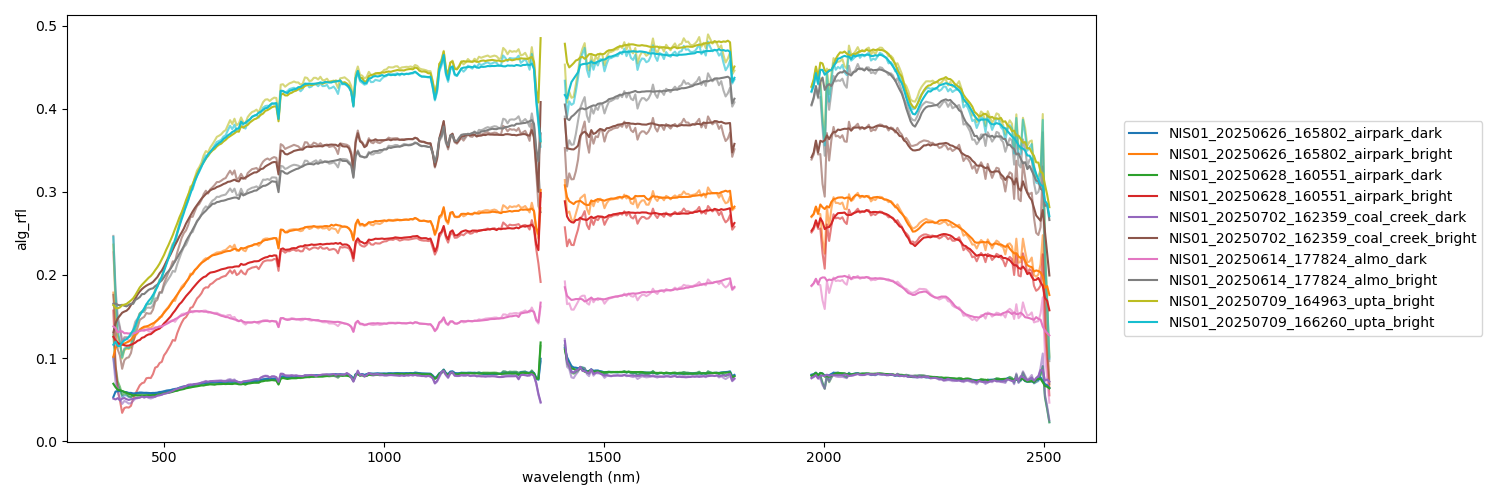

In [103]:
# viz alg rfl with and without rccs

fig = plt.figure(figsize=(15,5))

for i in range(len(alg_rfl_with_rcc)):
    plt.plot(wl_nan, alg_rfl_without_rcc[i], alpha=0.6)

for i in range(len(alg_rfl_with_rcc)):
    plt.plot(wl_nan, alg_rfl_with_rcc[i], label=rfl_labels[i])

plt.ylabel('alg_rfl')
plt.xlabel('wavelength (nm)')

plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()

plt.show()

In [5]:
fp_out = os.path.join(base_dir, 'rcc_snodgrass_mean_20251117_detrended_adjusted.txt')
# np.savetxt(fp_out, rcc_detrended_adjusted)
rcc_detrended_adjusted = np.loadtxt(fp_out)

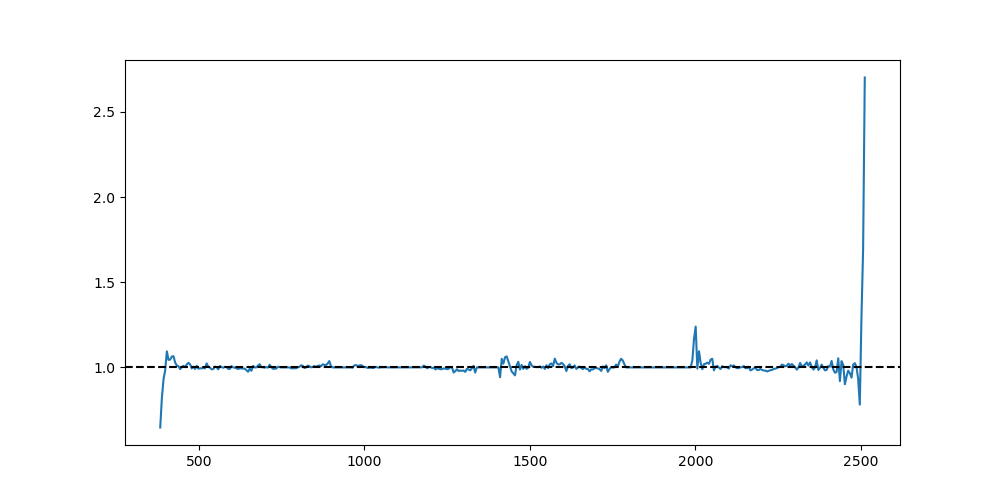

In [8]:
fig = plt.figure(figsize=(10,5))
plt.plot(wl, rcc_detrended_adjusted)
plt.axhline(1, linestyle='--', color='black')
plt.show()